In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import matplotlib.pyplot as plt
from utils import eval_basis_functions, get_coeff, single_stacked_kan_training

In [2]:
k=3
coarse_grid_size = 10
finer_grid_size = 20

preacts = torch.rand((100, 1))
postacts = torch.sin(preacts) + torch.randn(preacts.shape) * 0.1

# find the new control points
prev_grid = torch.linspace(-2.5, 2, steps=coarse_grid_size).unsqueeze(dim=0) # we need to increase the contorl points here

# learn the spline to predict the control points in the existing grid
x_pos = prev_grid.transpose(1,0)
temp_grid = torch.linspace(-1, 1, steps=coarse_grid_size).unsqueeze(dim=0)
temp_bases = eval_basis_functions(temp_grid.transpose(1, 0), temp_grid, k=1) # linear interpolate into a smaller grid
temp_coef = get_coeff(temp_bases, x_pos)

# let's predict more control points using the above spline
percentiles = torch.linspace(-1, 1, steps=finer_grid_size).unsqueeze(dim=1)
percentiles_basis = eval_basis_functions(percentiles, temp_grid, k=1)
new_grid = torch.einsum('ijk, bij-> bk', temp_coef, percentiles_basis).transpose(1, 0)
new_grid

# find the coefficients (predicitng the same postacts from preacts but using the new control points)
new_bases = eval_basis_functions(preacts, new_grid, k)
new_coef = get_coeff(new_bases, postacts)

In [3]:
def update_grid(prev_grid, new_grid_size, k, preacts, postacts):
    """
    Updates grid.

    Args:
        prev_grid: number of splines x number of control points
        new_grid_size: new number of control points
        k: spline-order
        preacts: inputs to the grid
        postacts: current outputs to the grid.

    Returns:
        new_coef: New coefficients to maintain the behavior of the current spline-activation
        new_grid: new grid with new control points
    """
    coarse_grid_size = prev_grid.shape[-1]
    finer_grid_size = new_grid_size

    # learn the spline to predict the control points in the existing grid
    x_pos = prev_grid.transpose(1,0)
    temp_grid = torch.linspace(-1, 1, steps=coarse_grid_size).unsqueeze(dim=0)
    temp_bases = eval_basis_functions(temp_grid.transpose(1, 0), temp_grid, k=1) # linear interpolate into a smaller grid
    temp_coef = get_coeff(temp_bases, x_pos)

    # let's predict more control points using the above spline
    percentiles = torch.linspace(-1, 1, steps=finer_grid_size).unsqueeze(dim=1)
    percentiles_basis = eval_basis_functions(percentiles, temp_grid, k=1)
    new_grid = torch.einsum('ijk, bij-> bk', temp_coef, percentiles_basis).transpose(1, 0)

    # find the coefficients (predicitng the same postacts from preacts but using the new control points)
    new_bases = eval_basis_functions(preacts, new_grid, k)
    new_coef = get_coeff(new_bases, postacts)

    return new_coef, new_grid

In [4]:
# fn, fn_label = lambda x: torch.sin(torch.pi * x),  '$sin(\pi x)$'
# fn, fn_label = (lambda x: torch.exp(torch.exp(-x)) + torch.sin(torch.pi * x) + torch.exp(torch.sin(x)), '$e^{e^{-x}} + sin(\pi \cdot x) + e^{sin(x)}$')
fn, fn_label = (lambda x: torch.exp(torch.sin(torch.pi* x) + x**2) + (1 / (1 + x**2)), '$f(x) = e^{sin(\pi x) + x^2} + \\frac{1}{1+x^2}$')

x_eval = torch.linspace(-1, 1, steps=999).unsqueeze(dim=1)
y_target = fn(x_eval) + 0.1 * torch.rand(x_eval.shape)

# test and train split
n_training = int(x_eval.shape[0] * 0.8)
training_idxs = np.random.randint(x_eval.shape[0], size=n_training)
test_idxs = [i for i in range(x_eval.shape[0]) if i not in training_idxs]
x_training = x_eval[training_idxs]
x_test = x_eval[test_idxs]
y_training = y_target[training_idxs]
y_test = y_target[test_idxs]


lr = 0.1
k = 2
n_layers = 1
grid_sizes = [3]
grid_range = [-1, 1]

loss_batches = []

params_kan, y_pred_kan, losses_kan, all_xs = single_stacked_kan_training(x_training, y_training, x_test, y_test, lr=lr,
                                                                         k=k, n_layers=n_layers,
                                                                         grid_sizes=grid_sizes, verbose=False,
                                                                         grid_range=[], use_scales=False)
loss_batches.append(losses_kan)

for new_grid_size in [5, 8, 10, 12]:
    prev_grid = params_kan['grids'][0]
    prev_coef = params_kan['coeffs'][0]
    postacts = all_xs[-1][0]
    new_coef, new_grid = update_grid(prev_grid, new_grid_size, k, x_training, postacts)

    new_coef = new_coef.requires_grad_(True)
    params_kan['grids'] = [new_grid]
    params_kan['coeffs'] = [new_coef]

    print(f"Increasing number of parameters to {new_grid_size}: Prev grid: {prev_grid.shape} New grid: {new_grid.shape} Prev. Coef: {prev_coef.shape} New Coef: {new_coef.shape}")

    params_kan, y_pred_kan, losses_kan, all_xs = single_stacked_kan_training(x_training, y_training, x_test, y_test, model_params=params_kan, lr=lr,
                                                                             k=k, n_layers=n_layers,
                                                                             grid_sizes=grid_sizes, verbose=False,
                                                                             grid_range=[], use_scales=False)


    loss_batches.append(losses_kan)

Stopping: No further improvements...
Increasing number of parameters to 5: Prev grid: torch.Size([1, 3]) New grid: torch.Size([1, 5]) Prev. Coef: torch.Size([1, 4, 1]) New Coef: torch.Size([1, 6, 1])
Stopping: No further improvements...
Increasing number of parameters to 8: Prev grid: torch.Size([1, 5]) New grid: torch.Size([1, 8]) Prev. Coef: torch.Size([1, 6, 1]) New Coef: torch.Size([1, 9, 1])
Stopping: Iteration limit reached...
Increasing number of parameters to 12: Prev grid: torch.Size([1, 10]) New grid: torch.Size([1, 12]) Prev. Coef: torch.Size([1, 11, 1]) New Coef: torch.Size([1, 13, 1])
Stopping: No further improvements...


Text(0.5, 1.0, 'Loss:\n$f(x) = e^{sin(\\pi x) + x^2} + \\frac{1}{1+x^2}$')

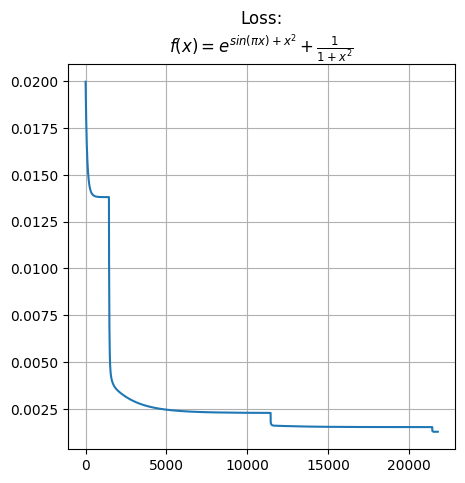

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), dpi=100)

ax = axs
ax.plot([x for losses in loss_batches for x in losses['val'] if x < 0.02])
ax.grid()
ax.set_title(f"Loss:\n{fn_label}")

In [6]:
def model_predict(params_kan, x_eval, k):
    """
    Implements prediction functions using raw KANs.
    """
    grids = params_kan['grids']
    coeffs = params_kan['coeffs']
    scale_bases = params_kan['scale_bases']
    scale_splines = params_kan['scale_splines']
    base_fns = params_kan['base_fns']

    for idx in range(len(grids)):
        grid, coeff = grids[idx], coeffs[idx]

        with torch.no_grad():
            x = torch.einsum('ijk, bij -> bk', coeff, eval_basis_functions(x_eval, grid, k))
            if len(base_fns) > 0:
                base_fn, scale_sp, scale_base =  base_fns[idx], scale_splines[idx], scale_bases[idx]
                x = scale_base * base_fn(x_eval) + scale_sp * x

        y_pred = x_eval = x


    return y_pred

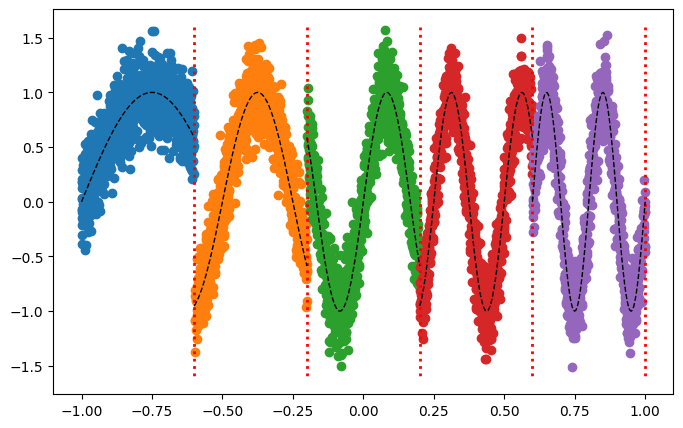

In [7]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

# Data generation parameters
n_samples_per_phase = 1000
noise_level = 0.2
n_phases = 5

for i in range(n_phases):
    start = -1 + i * 2/n_phases
    end = start + 2/n_phases
    x = torch.rand(n_samples_per_phase) * (end - start) + start

    y = torch.sin(2 * x * torch.pi * (i + 1))
    y_noisy = y + noise_level * torch.randn(y.shape)

    ax.scatter(x, y_noisy)
    ax.vlines(end, 1.6, -1.6, color='red', linestyle=':', linewidth=2)

    x_ = torch.linspace(start, end, 100)
    y_ = torch.sin(2 * x_ * torch.pi * (i + 1))
    ax.plot(x_, y_, color='black', linewidth=1, linestyle='--')

Stopping: No further improvements...
Phase: 0	Loss:  0.0429
Stopping: No further improvements...
Phase: 1	Loss:  0.0446
Stopping: No further improvements...
Phase: 2	Loss:  0.0413


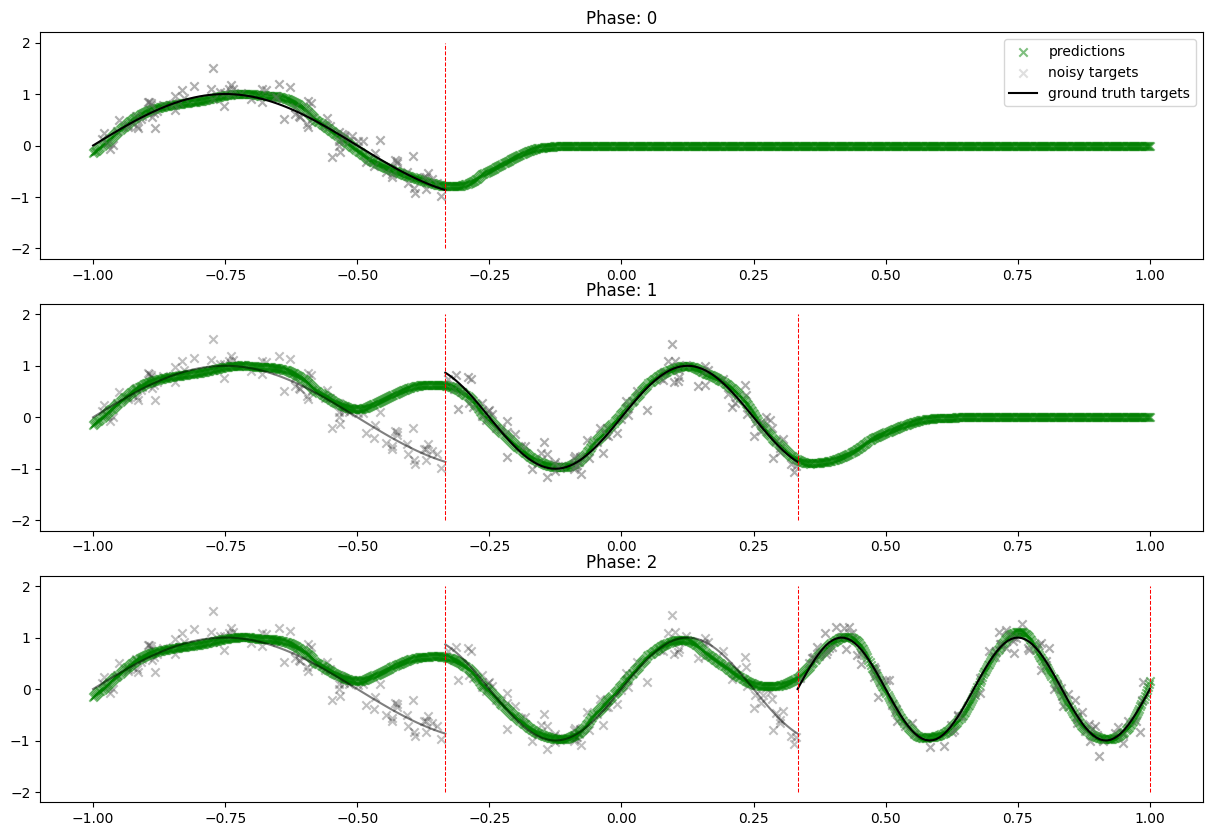

In [8]:
# Data generation parameters
n_samples_per_phase = 100
noise_level = 0.2
n_phases = 3

fig, axs = plt.subplots(nrows=n_phases, ncols=1, figsize=(15, 10), dpi=100)

losses = []
grid_sizes = [20]
grid_range = [-1, 1]
lr = 0.5
k = 3
n_layers = 1

params_kan = None
x_temps, y_temps, ends, y_noisys = [], [], [], []
for i in range(n_phases):

    # create this dataset
    start = -1 + i * 2/n_phases
    end = start + 2/n_phases
    fn = lambda x, i: torch.sin(2 * x * torch.pi * (i + 1))

    x = torch.rand(n_samples_per_phase) * (end - start) + start

    y = fn(x, i)
    y_noisy = y + noise_level * torch.randn(y.shape)

    # train the model
    x_eval = x.unsqueeze(dim=1)
    y_target = y_noisy.unsqueeze(dim=1)

    # test and train split
    n_training = int(x_eval.shape[0] * 0.8)
    training_idxs = np.random.randint(x_eval.shape[0], size=n_training)
    test_idxs = [i for i in range(x_eval.shape[0]) if i not in training_idxs]
    x_training = x_eval[training_idxs]
    x_test = x_eval[test_idxs]
    y_training = y_target[training_idxs]
    y_test = y_target[test_idxs]

    # train using the same model (model_params=params_kan)
    params_kan, y_pred_kan, losses_kan, all_xs = single_stacked_kan_training(x_training, y_training, x_test, y_test, lr=lr, model_params=params_kan,
                                                                             k=k, n_layers=n_layers,
                                                                             grid_sizes=grid_sizes, verbose=False,
                                                                             grid_range=[], use_scales=False)

    losses.append(losses_kan)
    print(f"Phase: {i}\tLoss: {np.mean(losses_kan['val'][-50:]): 0.4f}")

    # predictions vs target
    ax = axs[i]
    ax.scatter(x, y_noisy, color='black', marker='x', alpha=0.25)
    for temp_x, temp_y in y_noisys:
        ax.scatter(temp_x, temp_y, color='black', alpha=0.25, marker='x')

    y_noisys.append((x, y_noisy))


    x_in = torch.linspace(-1, 1, 1000).unsqueeze(dim=1)
    y_pred = model_predict(params_kan, x_in, k)
    ax.scatter(x_in[:, 0], y_pred, color='green', alpha=0.5, marker='x', label="predictions")
    ax.scatter(x, y_noisy, color='grey', marker='x', alpha=0.25, label="noisy targets")

    x_temp = torch.linspace(0, 1, 100) * (end - start) + start
    y_temp = fn(x_temp, i)

    ax.plot(x_temp, y_temp, linestyle='-',  color='black', label="ground truth targets")
    for x,y in zip(x_temps, y_temps):
        ax.plot(x, y, linestyle='-', alpha=0.5, color='black')

    ends.append(end)
    for x in ends:
        ax.vlines(x, -2, 2, linestyle='--', color='red', linewidth=0.75)

    ax.set_title(f"Phase: {i}")
    if i == 0:
        ax.legend()

    x_temps.append(x_temp)
    y_temps.append(y_temp)